# ⚛︎ Hyperuniform sampling with the finufft (for 2D/3D point clouds)

# GPU configuration:

- GPU configuration is optional, and definitely *not needed* if the number of sampled points is <= 100k.
- For large datasets, it will make the sampler run much faster than the CPU version.  First select the GPU-T4 runtime of google colab and then install finufft with cuda, which is done by runing the cell bellow.
- this command work only for google colab GPU. For an other GPU it might need to be adapted.


In [1]:
install_GPU = False

if install_GPU:
    try:
        # Colab GPU — install Conda + native cuFINUFFT/CuPy
        !pip -q install condacolab

        import condacolab
        condacolab.install()

        !conda install -y -c conda-forge cufinufft cupy

        device = "gpu"

    except Exception as e:
        print(f"[config] GPU setup failed: {e}")
        print("[config] Falling back to CPU.")
        device = "cpu"

else:
    device = "cpu"

print(f"[config] device = {device}")

[config] device = cpu


# Float precision configuration

- float32 always recomanded besides if S(k) << 10^-10 is required.
- The sampler can go as far as S(k) = 10^-20 using float64 computation,
but float64 is SLOW

In [3]:
precision = "float32" #or float64

# Required packages

This might need to be adapted depending on operating system etc.

In [2]:
import os, sys, subprocess
from types import SimpleNamespace

cfg = SimpleNamespace()

def set_config(device="cpu", precision="float32", install=True, verbose = 1):
    if verbose >= 1:
        print("set_config() might need to be adapted depending on operating system")
    device = device.lower()
    precision = "float64" if precision in ("float64", "double") else "float32"

    if install:
        pkgs = ["cupy-cuda12x", "cufinufft", "jax", "blue_sampler"] if device == "gpu" else ["finufft", "jax[CPU]", "blue_sampler"]
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs, "blue-sampler"],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    if device == "gpu":
        import cupy as cp, cufinufft as nufft
        xp, to_numpy = cp, cp.asnumpy
    else:
        import numpy as np, finufft as nufft
        xp, to_numpy = np, np.asarray

    if precision == "float64":
        real, cplx, plan_dt = xp.float64, xp.complex128, "complex128"
    else:
        real, cplx, plan_dt = xp.float32, xp.complex64, "complex64"

    try:
        os.environ["JAX_PLATFORMS"] = "cpu"
        import jax
        jax.config.update("jax_enable_x64", precision == "float64")
    except Exception:
        pass

    cfg.__dict__.update(
        device=device, precision=precision, xp=xp, nufft_lib=nufft,
        to_numpy=to_numpy, real_dtype=real, complex_dtype=cplx,
        plan_dtype=plan_dt
    )
    if verbose >= 1:
        print(f"[config] {cfg.device} | {precision} | dtype={cfg.real_dtype}")
    return cfg

cfg = set_config(device, precision)
import numpy as np
import matplotlib.pyplot as plt
import blue_sampler as blue
import time

# Sampler

- based on a **spectral loss** on all the S(k), k <= Kmax.
- the spectral loss computation has **log-linear complexity** instead of naive quadratic thanks to the non uniform *fast fourier transform*.
- a *scheduler* is applyed to scale the gradient step at each iteration. A good scheduler is **cruciall** for the gradient descent to go well.

In [5]:
def sample_blue_nufft(N = 10_000, D = 2, Chi = 0.4, n_iter = 1000, seed = 0, verbose = 1, cfg = cfg):
    if D not in (1, 2, 3):
        raise ValueError(f"Only D=1,2,3 supported (got {D})")

    # ---------- read the configuration (GPU/CPU, Float/Double) ----------
    xp          = cfg.xp
    real_dtype  = cfg.real_dtype
    complex_dtype = cfg.complex_dtype
    device = cfg.device
    precision = cfg.precision
    to_numpy = cfg.to_numpy
    nufft_lib = cfg.nufft_lib

    eps = 1e-5 if precision == "float32" else 1e-10
    resolution = 1.5
    # ---------- geometry ----------
    if D == 2:
        kfrac = float(np.sqrt(2 / np.pi) * 2 * Chi)
    elif D == 3:
        kfrac = float((2 / ((4 / 3) * np.pi)) ** (1 / 3) * 2 * Chi)
    else:
        kfrac = 2.0 * Chi

    rng = np.random.default_rng(seed)
    x = xp.asarray(rng.uniform(size=(N, D)), dtype=real_dtype)

    G = int(np.ceil(N ** (1.0 / D)) * resolution)
    if G % 2:
        G += 1
    n_modes = (G,) * D

    # frequencies (FFT order)
    freqs = xp.fft.fftfreq(G).astype(real_dtype) * G
    if D == 1:
        ks = (freqs,)
    else:
        ks = xp.meshgrid(*[freqs] * D, indexing="ij")

    r2 = sum(k**2 for k in ks)
    rpow = (r2 + 1e-3) ** (-1.0)
    mask = (r2 > 0) & (r2 <= (G * min(kfrac / resolution, 1.0)) ** 2)
    w = xp.where(mask, rpow, 0.0).astype(real_dtype)
    norm = float(xp.maximum(mask.sum(), 1.0))
    w = w / w.max()

    # ---------- plans (réutilisables) ----------
    plan_kwargs = dict(
        n_trans=1,
        eps=eps,
        isign=1,
        dtype=complex_dtype,
        modeord=1,
    )
    plan1 = nufft_lib.Plan(1, n_modes, **plan_kwargs)  # type-1 (forward)
    plan2 = nufft_lib.Plan(2, n_modes, **plan_kwargs)  # type-2 (backward)

    c = xp.ones(N, dtype=complex_dtype)

    def loss_and_grad(x: xp.ndarray):
        coords = tuple(2.0 * xp.pi * x[:, d] for d in range(D))

        plan1.setpts(*coords)
        fk = plan1.execute(c)

        loss = float(xp.sum(xp.abs(fk) ** 2 * w) / norm)

        grads = []
        for d in range(D):
            grad_source = (2.0 * w * xp.conj(fk) * (1j * 2.0 * xp.pi * ks[d])).astype(
                complex_dtype
            )
            plan2.setpts(*coords)
            g_d = plan2.execute(grad_source)
            grads.append(g_d.real)

        grad = xp.stack(grads, axis=1) / norm
        return loss, grad

    # ---------- scheduled gradient descent ----------
    delta = 0.1 * N ** (-1.0 / D)

    if verbose:
        print(
            f"[nufft | {device} | {precision}] "
            f"N={N}  D={D}  G={G}  kfrac={kfrac:.4f}  "
            f"n_iter={n_iter}  delta={delta:.4f}"
        )
        print("For Early-stopping : Ctrl-C (Keyboard interrupt ⏹️)")

    t0 = time.time()
    adaptive = delta
    prev_loss = float("inf")

    # warm-up
    loss, grad = loss_and_grad(x)
    rms = xp.sqrt(xp.mean(grad**2) + 1e-30)
    x = x - (grad / rms) * adaptive
    x = x - xp.floor(x)
    prev_loss = loss

    try:
        for it in range(n_iter):
            envelope = float(np.exp(-5.0 * it / n_iter))
            schedule = adaptive * envelope

            loss, grad = loss_and_grad(x)
            rms = xp.sqrt(xp.mean(grad**2) + 1e-30)
            x_new = x - (grad / rms) * schedule
            x_new = x_new - xp.floor(x_new)

            if loss < prev_loss:
                x = x_new
                adaptive *= 1.05
                prev_loss = loss
            else:
                adaptive *= 0.95
                x = x_new

            if verbose and (it % 50 == 0 or it == n_iter - 1):
                print(f"  iter {it:4d} | loss {loss:.1e}")

    except KeyboardInterrupt:
        if verbose:
            print(f"\n  [KeyboardInterrupt] stopped at iter {it} | loss {loss:.4f}")
            print(f"  elapsed : {time.time() - t0:.1f}s")

    if verbose:
        print(f"  done in {time.time() - t0:.1f}s")

    return to_numpy(x)

#Run the sampling
with given N (number of points) D (dimension, <=3) and Chi (spectral bandwidth, <= 0.5)

[nufft | cpu | float32] N=10000  D=2  G=150  kfrac=0.6383  n_iter=1000  delta=0.0010
For Early-stopping : Ctrl-C (Keyboard interrupt ⏹️)
  iter    0 | loss 2.1e+01
  iter   50 | loss 6.8e-02
  iter  100 | loss 9.1e-03
  iter  150 | loss 1.8e-03
  iter  200 | loss 2.4e-04
  iter  250 | loss 4.7e-05
  iter  300 | loss 6.3e-06
  iter  350 | loss 1.2e-06
  iter  400 | loss 1.6e-07
  iter  450 | loss 2.3e-08
  iter  500 | loss 3.7e-09
  iter  550 | loss 1.2e-09
  iter  600 | loss 7.4e-10
  iter  650 | loss 4.4e-10
  iter  700 | loss 2.7e-10
  iter  750 | loss 2.0e-10
  iter  800 | loss 1.9e-10
  iter  850 | loss 1.8e-10
  iter  900 | loss 1.8e-10
  iter  950 | loss 1.8e-10
  iter  999 | loss 1.8e-10
  done in 7.0s


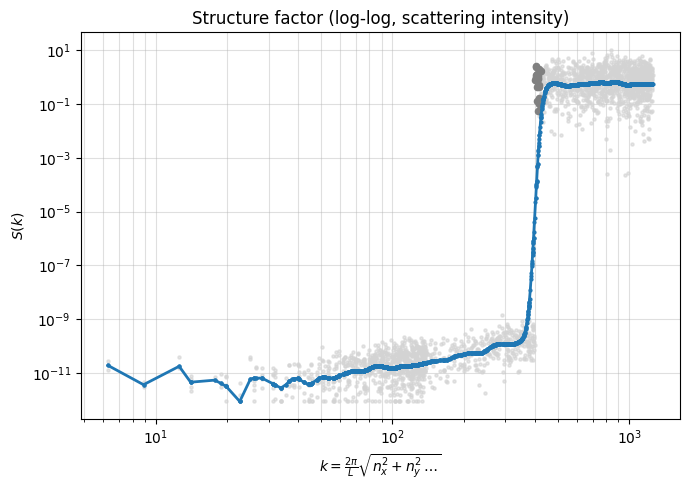

In [6]:
x = sample_blue_nufft(N = 10_000, D = 2, Chi = 0.4)
blue.plot_structure_factor(x)

#Plot the points
The points are auto zoomed for better visualisation

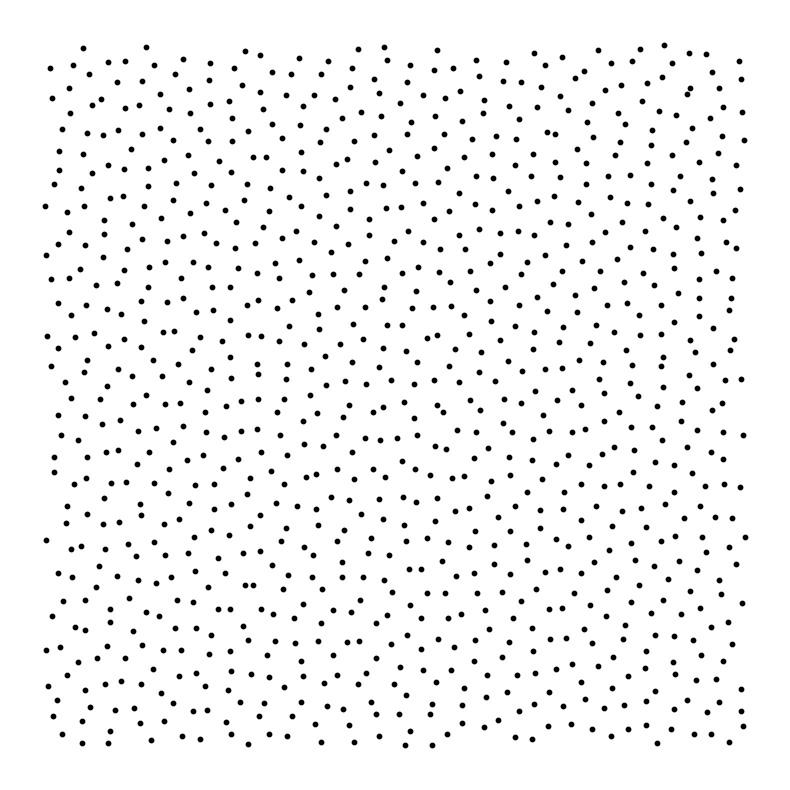

In [7]:
blue.plot(x, auto_zoom = True, max_points = 1000)

# Note the influence of the Chi parametter
which control the last frequency at wich we require S(k) << 1. Big Chi means more frequencies are controlled, but at the cost of a lower precision. Chi shall not go far beyond 0.5, because above we would ask more equation than the number of free parametters. Default value is Chi = 0.4

2D – Chi=0.4
2D – Chi=0.55


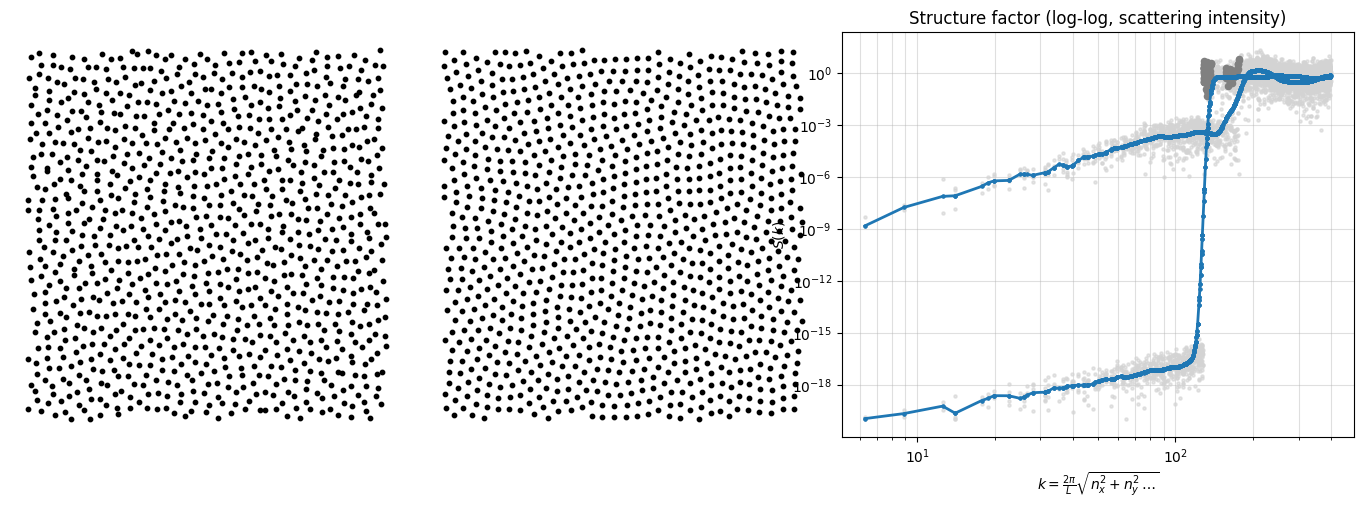

In [8]:
def Chi_experiment(D):
    cfg = set_config(device, precision="float64", verbose=0)

    N = 1_000
    chis = [0.4, 0.55]

    n = len(chis)
    nrows = (n + 1) // 2

    fig = plt.figure(figsize=(14, 4.5 * nrows))
    gs = fig.add_gridspec(nrows, 3, width_ratios=[1, 1, 1.3])

    axes_pts = []
    for i in range(n):
        r, c = divmod(i, 2)
        if D == 2:
            ax = fig.add_subplot(gs[r, c])
        else:
            ax = fig.add_subplot(gs[r, c], projection='3d')
        axes_pts.append(ax)

    ax_sf = fig.add_subplot(gs[:, 2])

    for i, Chi in enumerate(chis):
        print(f"{D}D – Chi={Chi}")
        x = sample_blue_nufft(N=N, D=D, Chi=Chi, verbose=0, cfg=cfg)
        _, _ = blue.plot(x, ax=axes_pts[i], return_fig=True)
        _, _ = blue.plot_structure_factor(x, ax=ax_sf, return_fig=True, label=f"χ={Chi}")

    plt.tight_layout()
    gs.update(wspace=0.05, hspace=0.15)
    fig.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05)
    plt.show()

    # restore original precision if needed
    cfg = set_config(device, precision=precision, verbose=0)

Chi_experiment(D=2)

3D – Chi=0.4
3D – Chi=0.55


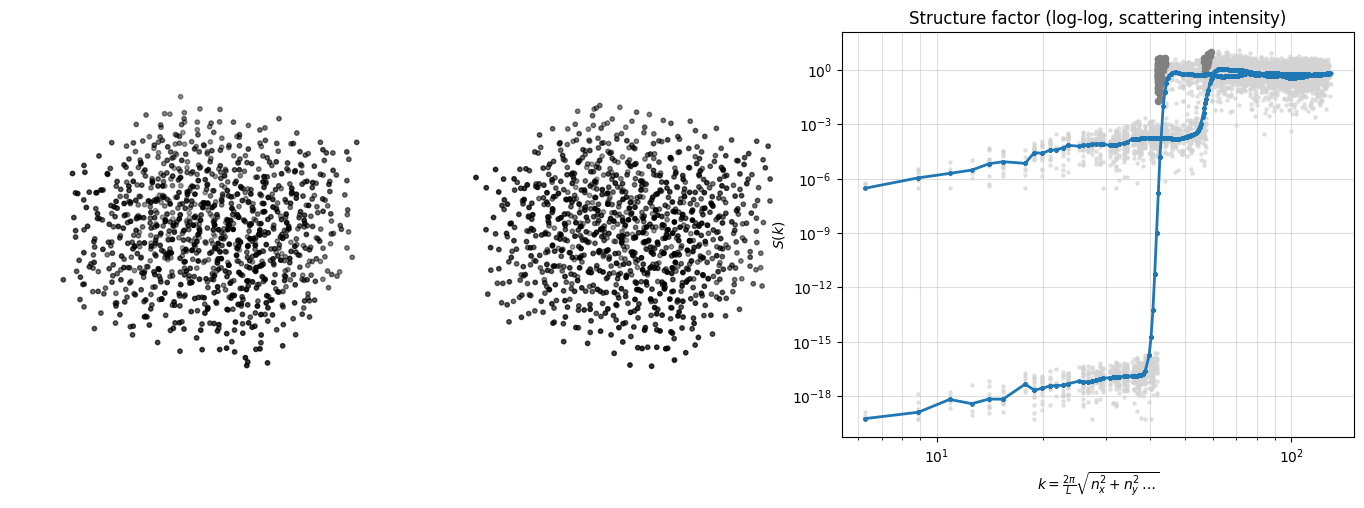

In [9]:
Chi_experiment(D=3)